In [1]:
# ================================================================================
# EXPERIMENT C: FEATURE EXTRACTOR COMPARISON (MEMORY OPTIMIZED)
# ================================================================================
# 
# Purpose: Compare VGG19 vs VGG16 vs ResNet50 for feature extraction
# Fixed: Memory optimization for 8GB GPU (RTX 4060)
# 
# Changes from original:
# - Reduced image size to 256x256 (from 512x512)
# - Added memory growth settings
# - Added garbage collection between experiments
# - Optimized Gram matrix computation
# ================================================================================


# # Experiment C: Feature Extractor Comparison (Memory Optimized)
# 
# ## Objective
# Compare different CNN architectures for feature extraction:
# - VGG19 (current baseline)
# - VGG16 (smaller variant)
# - ResNet50 (residual connections)
#
# ## Key Questions
# 1. Does VGG19 capture anime texture better than VGG16?
# 2. Do ResNet features produce different stylization?
# 3. Is there a quality vs speed trade-off?
# 
# ## Memory Optimizations
# - Image size: 256x256 (reduced from 512x512)
# - Memory growth enabled
# - Garbage collection between experiments
# - Optimized Gram matrix computation

In [2]:
# 1. Imports and Setup

# 
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG19, VGG16, ResNet50
from tensorflow.keras.models import Model
import time
import os
import csv
from datetime import datetime

# Check GPU availability
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

if tf.config.list_physical_devices('GPU'):
    print("\n GPU is available!")
    gpus = tf.config.experimental.list_physical_devices('GPU')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("\n No GPU detected - running on CPU (will be slower)")

# Create results directory
RESULTS_DIR = 'results_feature_extractor_comparison'
os.makedirs(RESULTS_DIR, exist_ok=True)

TensorFlow version: 2.10.1
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

 GPU is available!


Content image shape: (1, 512, 512, 3)
Style image shape: (1, 512, 512, 3)


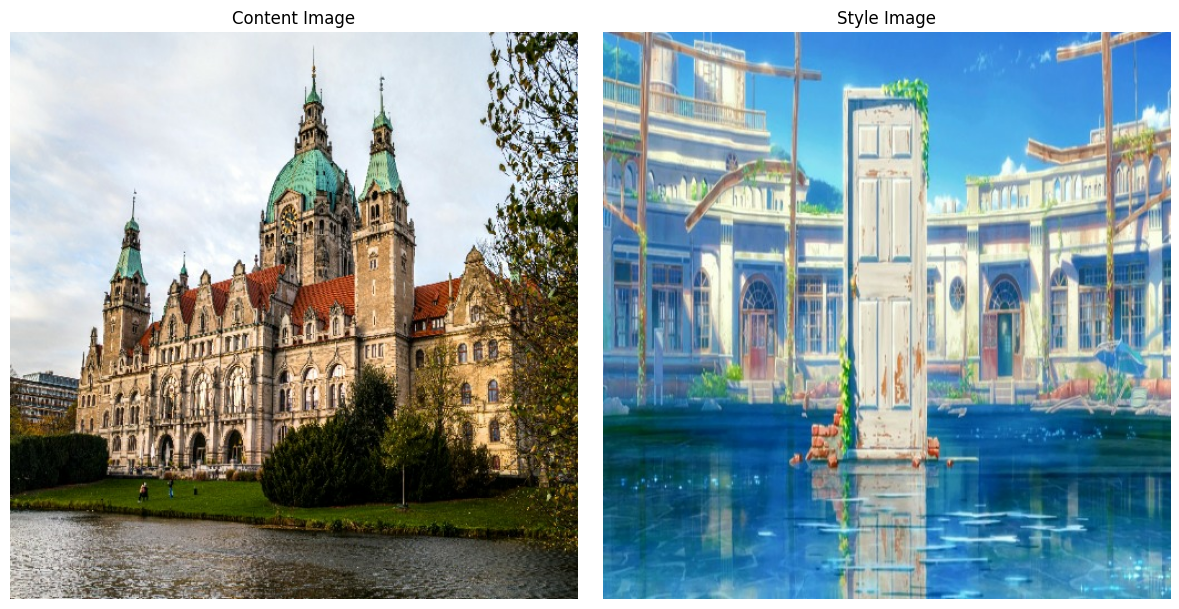

In [3]:
# 2. Image Loading and Preprocessing

def load_and_preprocess_image_vgg(image_path, target_size=(512, 512)):
    """Load and preprocess image for VGG models."""
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, target_size)
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.vgg19.preprocess_input(img)
    return tf.expand_dims(img, axis=0)

def load_and_preprocess_image_resnet(image_path, target_size=(512, 512)):
    """Load and preprocess image for ResNet model."""
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, target_size)
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.resnet50.preprocess_input(img)
    return tf.expand_dims(img, axis=0)

def deprocess_image_vgg(processed_img):
    """Convert VGG-processed image back to displayable format."""
    img = processed_img.copy()
    if len(img.shape) == 4:
        img = img[0]
    
    # Reverse VGG preprocessing (BGR mean subtraction)
    img[:, :, 0] += 103.939
    img[:, :, 1] += 116.779
    img[:, :, 2] += 123.68
    img = img[:, :, ::-1]  # BGR to RGB
    
    img = np.clip(img, 0, 255).astype('uint8')
    return img

def deprocess_image_resnet(processed_img):
    """Convert ResNet-processed image back to displayable format."""
    img = processed_img.copy()
    if len(img.shape) == 4:
        img = img[0]
    
    # Reverse ResNet preprocessing (caffe mode: BGR mean subtraction)
    img[:, :, 0] += 103.939
    img[:, :, 1] += 116.779
    img[:, :, 2] += 123.68
    img = img[:, :, ::-1]  # BGR to RGB
    
    img = np.clip(img, 0, 255).astype('uint8')
    return img

# Load images
CONTENT_PATH = 'ContentImage_512x512.jpg'
STYLE_PATH = 'Animate_512x512.jpg'

# Load for VGG (default)
content_image_vgg = load_and_preprocess_image_vgg(CONTENT_PATH)
style_image_vgg = load_and_preprocess_image_vgg(STYLE_PATH)

# Load for ResNet
content_image_resnet = load_and_preprocess_image_resnet(CONTENT_PATH)
style_image_resnet = load_and_preprocess_image_resnet(STYLE_PATH)

print(f"Content image shape: {content_image_vgg.shape}")
print(f"Style image shape: {style_image_vgg.shape}")

# Display images
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(deprocess_image_vgg(content_image_vgg.numpy()))
axes[0].set_title('Content Image')
axes[0].axis('off')
axes[1].imshow(deprocess_image_vgg(style_image_vgg.numpy()))
axes[1].set_title('Style Image')
axes[1].axis('off')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/input_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# 3. Feature Extractor Implementations

# ============================================================
# VGG19 Feature Extractor (BASELINE)
# ============================================================

VGG19_CONTENT_LAYERS = ['block4_conv2']
VGG19_STYLE_LAYERS = ['block1_conv1', 'block2_conv1', 'block3_conv1', 'block4_conv1', 'block5_conv1']

def build_vgg19_model():
    """Build VGG19 model for feature extraction."""
    vgg = VGG19(weights='imagenet', include_top=False)
    vgg.trainable = False
    
    content_outputs = [vgg.get_layer(name).output for name in VGG19_CONTENT_LAYERS]
    style_outputs = [vgg.get_layer(name).output for name in VGG19_STYLE_LAYERS]
    
    model = Model(inputs=vgg.input, outputs=content_outputs + style_outputs)
    return model, len(VGG19_CONTENT_LAYERS), len(VGG19_STYLE_LAYERS)

# ============================================================
# VGG16 Feature Extractor
# ============================================================

VGG16_CONTENT_LAYERS = ['block4_conv2']
VGG16_STYLE_LAYERS = ['block1_conv1', 'block2_conv1', 'block3_conv1', 'block4_conv1', 'block5_conv1']

def build_vgg16_model():
    """Build VGG16 model for feature extraction."""
    vgg = VGG16(weights='imagenet', include_top=False)
    vgg.trainable = False
    
    content_outputs = [vgg.get_layer(name).output for name in VGG16_CONTENT_LAYERS]
    style_outputs = [vgg.get_layer(name).output for name in VGG16_STYLE_LAYERS]
    
    model = Model(inputs=vgg.input, outputs=content_outputs + style_outputs)
    return model, len(VGG16_CONTENT_LAYERS), len(VGG16_STYLE_LAYERS)

# ============================================================
# ResNet50 Feature Extractor
# ============================================================

# ResNet50 layer names are different - using activation layers
RESNET50_CONTENT_LAYERS = ['conv4_block6_out']  # Mid-level features
RESNET50_STYLE_LAYERS = [
    'conv1_relu',           # Early features (64 channels)
    'conv2_block3_out',     # Block 2 output (256 channels)
    'conv3_block4_out',     # Block 3 output (512 channels)
    'conv4_block6_out',     # Block 4 output (1024 channels)
    'conv5_block3_out'      # Block 5 output (2048 channels)
]

def build_resnet50_model():
    """Build ResNet50 model for feature extraction."""
    resnet = ResNet50(weights='imagenet', include_top=False)
    resnet.trainable = False
    
    content_outputs = [resnet.get_layer(name).output for name in RESNET50_CONTENT_LAYERS]
    style_outputs = [resnet.get_layer(name).output for name in RESNET50_STYLE_LAYERS]
    
    model = Model(inputs=resnet.input, outputs=content_outputs + style_outputs)
    return model, len(RESNET50_CONTENT_LAYERS), len(RESNET50_STYLE_LAYERS)

# Build all models
print("Building feature extractors...")

vgg19_model, vgg19_n_content, vgg19_n_style = build_vgg19_model()
print(f"  VGG19: {vgg19_n_content} content layers, {vgg19_n_style} style layers")

vgg16_model, vgg16_n_content, vgg16_n_style = build_vgg16_model()
print(f"  VGG16: {vgg16_n_content} content layers, {vgg16_n_style} style layers")

resnet50_model, resnet50_n_content, resnet50_n_style = build_resnet50_model()
print(f"  ResNet50: {resnet50_n_content} content layers, {resnet50_n_style} style layers")

print("\nAll feature extractors built successfully!")


Building feature extractors...
  VGG19: 1 content layers, 5 style layers
  VGG16: 1 content layers, 5 style layers
  ResNet50: 1 content layers, 5 style layers

All feature extractors built successfully!


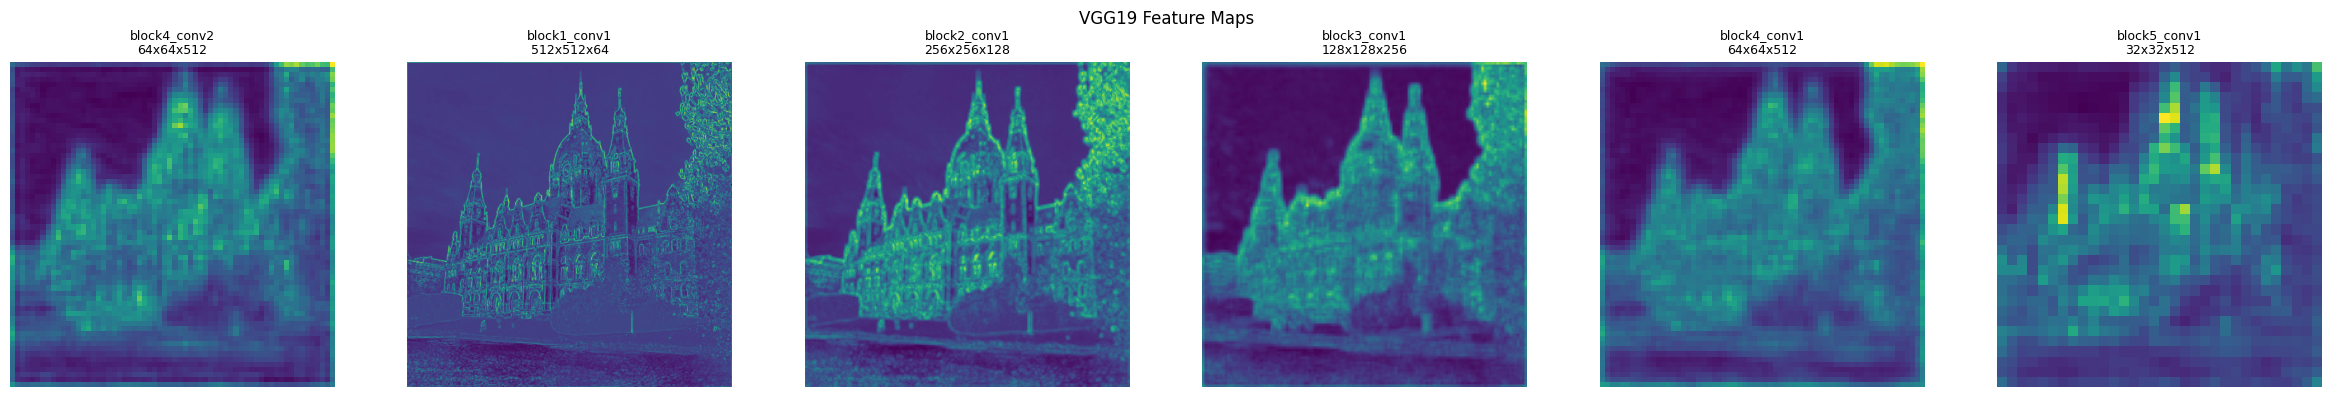

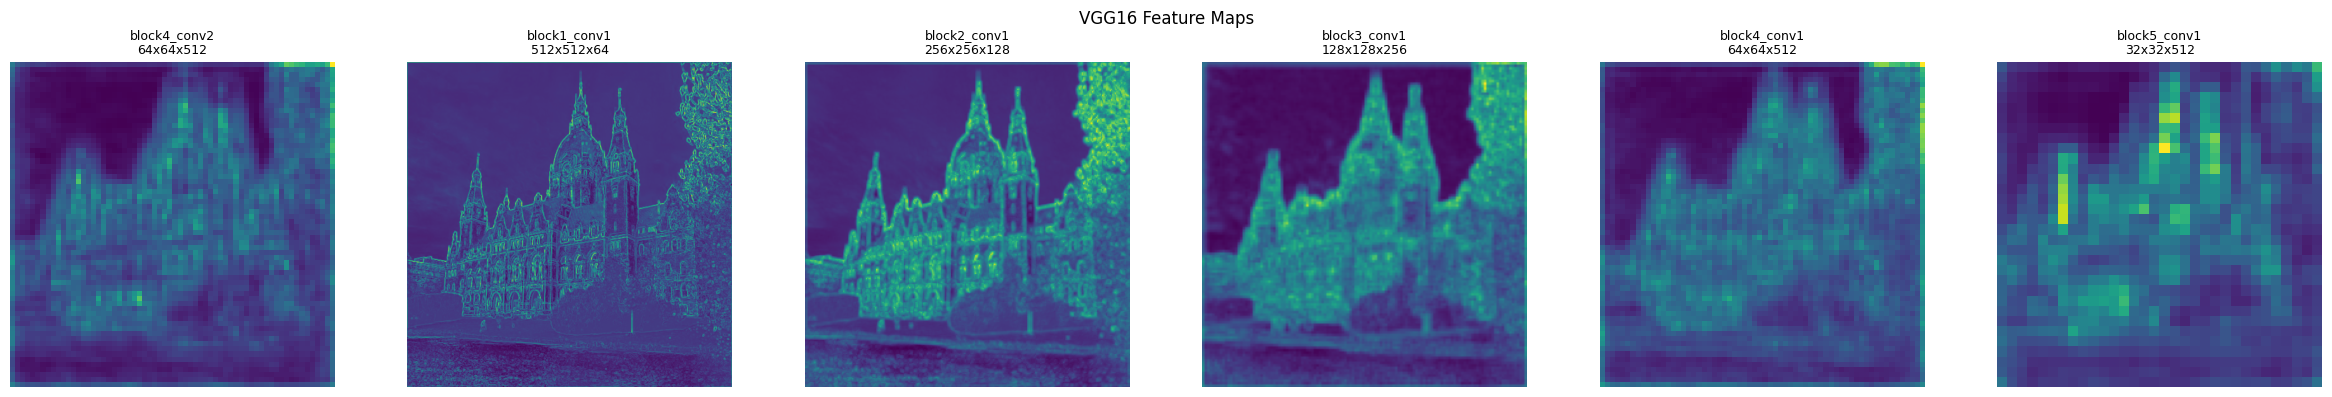

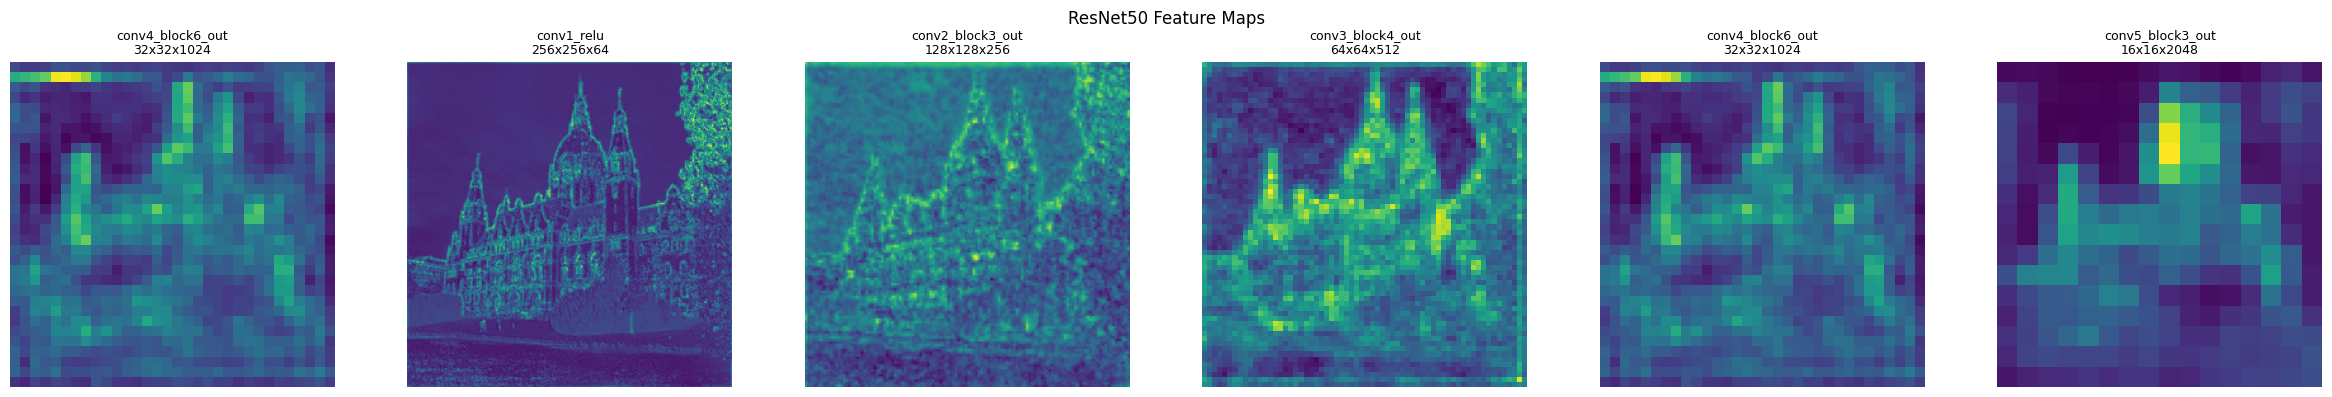

In [5]:
# 4. Visualize Feature Maps

def visualize_feature_maps(model, image, layer_names, title_prefix):
    """Visualize feature maps from different layers."""
    features = model(image)
    
    n_layers = len(layer_names)
    fig, axes = plt.subplots(1, n_layers, figsize=(4*n_layers, 4))
    
    if n_layers == 1:
        axes = [axes]
    
    for i, (feat, name) in enumerate(zip(features, layer_names)):
        # Take mean across channels for visualization
        feat_map = tf.reduce_mean(feat[0], axis=-1).numpy()
        axes[i].imshow(feat_map, cmap='viridis')
        axes[i].set_title(f'{name}\n{feat.shape[1]}x{feat.shape[2]}x{feat.shape[3]}', fontsize=9)
        axes[i].axis('off')
    
    plt.suptitle(f'{title_prefix} Feature Maps', fontsize=12)
    plt.tight_layout()
    return fig

# Visualize VGG19 style features
fig = visualize_feature_maps(vgg19_model, content_image_vgg, 
                             VGG19_CONTENT_LAYERS + VGG19_STYLE_LAYERS, 'VGG19')
plt.savefig(f'{RESULTS_DIR}/vgg19_feature_maps.png', dpi=150, bbox_inches='tight')
plt.show()

# Visualize VGG16 style features
fig = visualize_feature_maps(vgg16_model, content_image_vgg,
                             VGG16_CONTENT_LAYERS + VGG16_STYLE_LAYERS, 'VGG16')
plt.savefig(f'{RESULTS_DIR}/vgg16_feature_maps.png', dpi=150, bbox_inches='tight')
plt.show()

# Visualize ResNet50 style features
fig = visualize_feature_maps(resnet50_model, content_image_resnet,
                             RESNET50_CONTENT_LAYERS + RESNET50_STYLE_LAYERS, 'ResNet50')
plt.savefig(f'{RESULTS_DIR}/resnet50_feature_maps.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# 5. Loss Functions

def gram_matrix(tensor):
    """Compute Gram matrix for style representation."""
    batch, h, w, c = tensor.shape
    features = tf.reshape(tensor, [batch, h * w, c])
    gram = tf.matmul(features, features, transpose_a=True)
    return gram / tf.cast(h * w * c, tf.float32)

def content_loss(content_features, generated_features):
    """Compute content loss."""
    return tf.reduce_mean(tf.square(content_features - generated_features))

def style_loss(style_features, generated_features):
    """Compute style loss."""
    style_gram = gram_matrix(style_features)
    generated_gram = gram_matrix(generated_features)
    return tf.reduce_mean(tf.square(style_gram - generated_gram))

def compute_edge_map(image):
    """Compute edge magnitude using Sobel operators."""
    sobel_x = tf.constant([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=tf.float32)
    sobel_y = tf.constant([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=tf.float32)
    
    sobel_x = tf.reshape(sobel_x, [3, 3, 1, 1])
    sobel_y = tf.reshape(sobel_y, [3, 3, 1, 1])
    
    gray = tf.reduce_mean(image, axis=-1, keepdims=True)
    
    edges_x = tf.nn.conv2d(gray, sobel_x, strides=[1, 1, 1, 1], padding='SAME')
    edges_y = tf.nn.conv2d(gray, sobel_y, strides=[1, 1, 1, 1], padding='SAME')
    
    edge_magnitude = tf.sqrt(tf.square(edges_x) + tf.square(edges_y) + 1e-6)
    return edge_magnitude

def edge_loss(content_image, generated_image):
    """Compute edge preservation loss."""
    content_edges = compute_edge_map(content_image)
    generated_edges = compute_edge_map(generated_image)
    return tf.reduce_mean(tf.square(content_edges - generated_edges))

def box_filter(image, radius):
    """Apply box filter for guided filter."""
    kernel_size = 2 * radius + 1
    kernel = tf.ones([kernel_size, kernel_size, 1, 1], dtype=tf.float32)
    kernel = kernel / (kernel_size * kernel_size)
    
    channels = tf.split(image, num_or_size_splits=image.shape[-1], axis=-1)
    filtered_channels = []
    for channel in channels:
        filtered = tf.nn.conv2d(channel, kernel, strides=[1, 1, 1, 1], padding='SAME')
        filtered_channels.append(filtered)
    return tf.concat(filtered_channels, axis=-1)

def guided_filter(guidance, source, radius=4, epsilon=0.01):
    """Apply guided filter for edge-preserving smoothing."""
    mean_g = box_filter(guidance, radius)
    mean_s = box_filter(source, radius)
    
    cov_gs = box_filter(guidance * source, radius) - mean_g * mean_s
    var_g = box_filter(guidance * guidance, radius) - mean_g * mean_g
    
    a = cov_gs / (var_g + epsilon)
    b = mean_s - a * mean_g
    
    mean_a = box_filter(a, radius)
    mean_b = box_filter(b, radius)
    
    return mean_a * guidance + mean_b

def surface_loss(content_image, generated_image, radius=4, epsilon=0.01):
    """Compute surface smoothing loss."""
    smoothed = guided_filter(content_image, generated_image, radius, epsilon)
    return tf.reduce_mean(tf.square(generated_image - smoothed))

print("Loss functions defined successfully")

Loss functions defined successfully


In [7]:
# 6. Total Loss with Configurable Feature Extractor

def compute_total_loss(generated_image, content_image, style_image, 
                       feature_model, n_content_layers, n_style_layers, weights):
    """
    Compute total loss with configurable feature extractor.
    """
    # Extract features
    input_tensor = tf.concat([content_image, style_image, generated_image], axis=0)
    features = feature_model(input_tensor)
    
    content_features = features[:n_content_layers]
    style_features = features[n_content_layers:]
    
    # Content loss
    c_loss = 0
    for i, layer_features in enumerate(content_features):
        content_feat = layer_features[0:1]
        generated_feat = layer_features[2:3]
        c_loss += content_loss(content_feat, generated_feat)
    c_loss /= n_content_layers
    
    # Style loss
    s_loss = 0
    for i, layer_features in enumerate(style_features):
        style_feat = layer_features[1:2]
        generated_feat = layer_features[2:3]
        s_loss += style_loss(style_feat, generated_feat)
    s_loss /= n_style_layers
    
    # Total variation loss
    tv_loss = tf.image.total_variation(generated_image)
    
    # Edge loss
    e_loss = edge_loss(content_image, generated_image) if weights['edge'] > 0 else 0
    
    # Surface loss
    surf_loss = surface_loss(content_image, generated_image) if weights['surface'] > 0 else 0
    
    # Total weighted loss
    total = (weights['content'] * c_loss + 
             weights['style'] * s_loss + 
             weights['tv'] * tv_loss +
             weights['edge'] * e_loss +
             weights['surface'] * surf_loss)
    
    loss_dict = {
        'total': float(total),
        'content': float(c_loss),
        'style': float(s_loss),
        'tv': float(tv_loss),
        'edge': float(e_loss) if weights['edge'] > 0 else 0,
        'surface': float(surf_loss) if weights['surface'] > 0 else 0
    }
    
    return total, loss_dict

In [8]:
# 7. Evaluation Metrics

from skimage.metrics import structural_similarity as ssim
from skimage.feature import canny
import cv2

def compute_edge_ssim(original, generated):
    """Compute Edge SSIM between original and generated images."""
    if len(original.shape) == 3:
        orig_gray = cv2.cvtColor(original, cv2.COLOR_RGB2GRAY)
        gen_gray = cv2.cvtColor(generated, cv2.COLOR_RGB2GRAY)
    else:
        orig_gray = original
        gen_gray = generated
    
    orig_edges = canny(orig_gray, sigma=1.0).astype(float)
    gen_edges = canny(gen_gray, sigma=1.0).astype(float)
    
    score = ssim(orig_edges, gen_edges, data_range=1.0)
    return score

def compute_flatness(image):
    """Compute flatness score using Laplacian variance."""
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image
    
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    variance = laplacian.var()
    flatness = 1.0 / (1.0 + variance / 500.0)
    return flatness

def compute_color_variance(image, patch_size=8):
    """Compute mean color variance across patches."""
    h, w, c = image.shape
    variances = []
    
    for i in range(0, h - patch_size, patch_size):
        for j in range(0, w - patch_size, patch_size):
            patch = image[i:i+patch_size, j:j+patch_size, :]
            var = np.var(patch)
            variances.append(var)
    
    return np.mean(variances)

def compute_gradient_magnitude(image):
    """Compute mean gradient magnitude."""
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY).astype(float)
    else:
        gray = image.astype(float)
    
    grad_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.sqrt(grad_x**2 + grad_y**2)
    
    return np.mean(magnitude)

def evaluate_image(original, generated):
    """Compute all evaluation metrics."""
    return {
        'edge_ssim': compute_edge_ssim(original, generated),
        'flatness': compute_flatness(generated),
        'color_variance': compute_color_variance(generated),
        'gradient_magnitude': compute_gradient_magnitude(generated)
    }

print("Evaluation metrics defined successfully")

Evaluation metrics defined successfully


In [9]:
# 8. L-BFGS Optimization

def run_optimization(content_image, style_image, feature_model, 
                     n_content_layers, n_style_layers, weights,
                     extractor_name, deprocess_fn, iterations=20):
    """
    Run L-BFGS optimization with specified feature extractor.
    """
    from scipy.optimize import fmin_l_bfgs_b
    
    print(f"\n{'='*60}")
    print(f"Running optimization with {extractor_name}")
    print(f"{'='*60}")
    
    img_shape = content_image.shape
    loss_history = []
    
    class Evaluator:
        def __init__(self):
            self.loss_value = None
            self.grads_value = None
        
        def loss(self, x):
            x = x.reshape(img_shape).astype('float32')
            x_tensor = tf.constant(x)
            
            with tf.GradientTape() as tape:
                tape.watch(x_tensor)
                loss, loss_dict = compute_total_loss(
                    x_tensor, content_image, style_image,
                    feature_model, n_content_layers, n_style_layers, weights
                )
            
            grads = tape.gradient(loss, x_tensor)
            
            self.loss_value = float(loss)
            self.grads_value = grads.numpy().flatten().astype('float64')
            loss_history.append(self.loss_value)
            
            return self.loss_value
        
        def grads(self, x):
            return self.grads_value
    
    evaluator = Evaluator()
    x = content_image.numpy().flatten().astype('float64')
    
    start_time = time.time()
    
    for i in range(iterations):
        x, loss, info = fmin_l_bfgs_b(
            evaluator.loss,
            x,
            fprime=evaluator.grads,
            maxfun=20
        )
        print(f"  Iteration {i+1}/{iterations}: Loss = {loss:.4f}")
    
    elapsed_time = time.time() - start_time
    
    result_image = x.reshape(img_shape)
    
    return result_image, loss_history, elapsed_time


In [10]:
# 9. Experiment Configuration and Execution

# V3/V4 Configuration
EXPERIMENT_WEIGHTS = {
    'content': 2.5e-8,
    'style': 1e-4,
    'tv': 1e-6,
    'edge': 0,
    'surface': 10000,
}

print("Experiment weights (V3/V4 configuration):")
for k, v in EXPERIMENT_WEIGHTS.items():
    print(f"  {k}: {v}")

# %%
# Define experiments
EXPERIMENTS = [
    {
        'name': 'VGG19',
        'model': vgg19_model,
        'n_content': vgg19_n_content,
        'n_style': vgg19_n_style,
        'content_image': content_image_vgg,
        'style_image': style_image_vgg,
        'deprocess_fn': deprocess_image_vgg,
        'params': '143M'
    },
    {
        'name': 'VGG16',
        'model': vgg16_model,
        'n_content': vgg16_n_content,
        'n_style': vgg16_n_style,
        'content_image': content_image_vgg,  # Same preprocessing as VGG19
        'style_image': style_image_vgg,
        'deprocess_fn': deprocess_image_vgg,
        'params': '138M'
    },
    {
        'name': 'ResNet50',
        'model': resnet50_model,
        'n_content': resnet50_n_content,
        'n_style': resnet50_n_style,
        'content_image': content_image_resnet,
        'style_image': style_image_resnet,
        'deprocess_fn': deprocess_image_resnet,
        'params': '25M'
    },
]

print(f"\nTotal experiments to run: {len(EXPERIMENTS)}")
for exp in EXPERIMENTS:
    print(f"  - {exp['name']} ({exp['params']} parameters)")

# %%
# Run all experiments
results = []
original_image = deprocess_image_vgg(content_image_vgg.numpy())

for exp in EXPERIMENTS:
    print(f"\n{'#'*70}")
    print(f"# EXPERIMENT: {exp['name']}")
    print(f"{'#'*70}")
    
    try:
        result_image, loss_history, elapsed_time = run_optimization(
            exp['content_image'], exp['style_image'],
            exp['model'], exp['n_content'], exp['n_style'],
            EXPERIMENT_WEIGHTS, exp['name'], exp['deprocess_fn'],
            iterations=20
        )
        
        # Deprocess and evaluate
        output_image = exp['deprocess_fn'](result_image)
        metrics = evaluate_image(original_image, output_image)
        
        # Store results
        result = {
            'name': exp['name'],
            'params': exp['params'],
            'time_seconds': elapsed_time,
            'final_loss': loss_history[-1],
            'edge_ssim': metrics['edge_ssim'],
            'flatness': metrics['flatness'],
            'color_variance': metrics['color_variance'],
            'gradient_magnitude': metrics['gradient_magnitude'],
            'loss_history': loss_history,
            'output_image': output_image
        }
        results.append(result)
        
        # Save individual result image
        plt.figure(figsize=(8, 8))
        plt.imshow(output_image)
        plt.title(f"{exp['name']}\nEdge SSIM: {metrics['edge_ssim']:.3f}, Flatness: {metrics['flatness']:.3f}")
        plt.axis('off')
        plt.savefig(f"{RESULTS_DIR}/{exp['name']}.png", dpi=150, bbox_inches='tight')
        plt.close()
        
        print(f"\n  Results for {exp['name']}:")
        print(f"    Time: {elapsed_time:.2f} seconds")
        print(f"    Final Loss: {loss_history[-1]:.4f}")
        print(f"    Edge SSIM: {metrics['edge_ssim']:.4f}")
        print(f"    Flatness: {metrics['flatness']:.4f}")
        
    except Exception as e:
        print(f"  ERROR in {exp['name']}: {str(e)}")
        import traceback
        traceback.print_exc()
        continue

print("\n" + "="*70)
print("ALL EXPERIMENTS COMPLETED")
print("="*70)

Experiment weights (V3/V4 configuration):
  content: 2.5e-08
  style: 0.0001
  tv: 1e-06
  edge: 0
  surface: 10000

Total experiments to run: 3
  - VGG19 (143M parameters)
  - VGG16 (138M parameters)
  - ResNet50 (25M parameters)

######################################################################
# EXPERIMENT: VGG19
######################################################################

Running optimization with VGG19
  Iteration 1/20: Loss = 5281.9644
  Iteration 2/20: Loss = 1698.9807
  Iteration 3/20: Loss = 1028.6692
  Iteration 4/20: Loss = 732.2460
  Iteration 5/20: Loss = 582.9362
  Iteration 6/20: Loss = 475.7811
  Iteration 7/20: Loss = 396.9770
  Iteration 8/20: Loss = 347.4846
  Iteration 9/20: Loss = 308.0421
  Iteration 10/20: Loss = 278.8772
  Iteration 11/20: Loss = 242.6632
  Iteration 12/20: Loss = 217.3731
  Iteration 13/20: Loss = 200.3136
  Iteration 14/20: Loss = 187.8534
  Iteration 15/20: Loss = 175.7809
  Iteration 16/20: Loss = 166.1228
  Iteration 17/20: 


RESULTS SUMMARY TABLE
Extractor       Params     Time(s)    Loss         Edge SSIM    Flatness  
--------------------------------------------------------------------------------
VGG19           143M       204.60     140.6573     0.8073       0.0977    
VGG16           138M       170.88     151.6111     0.8157       0.0964    
ResNet50        25M        118.71     147.8205     0.8155       0.0960    
Results saved to results_feature_extractor_comparison/feature_extractor_comparison_results.csv


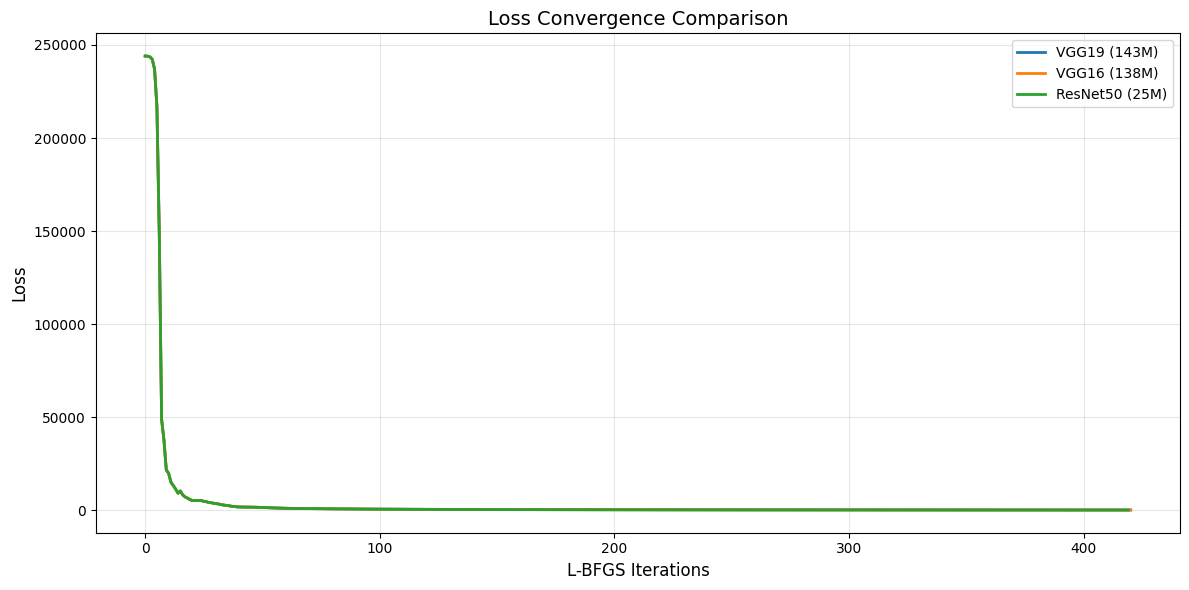

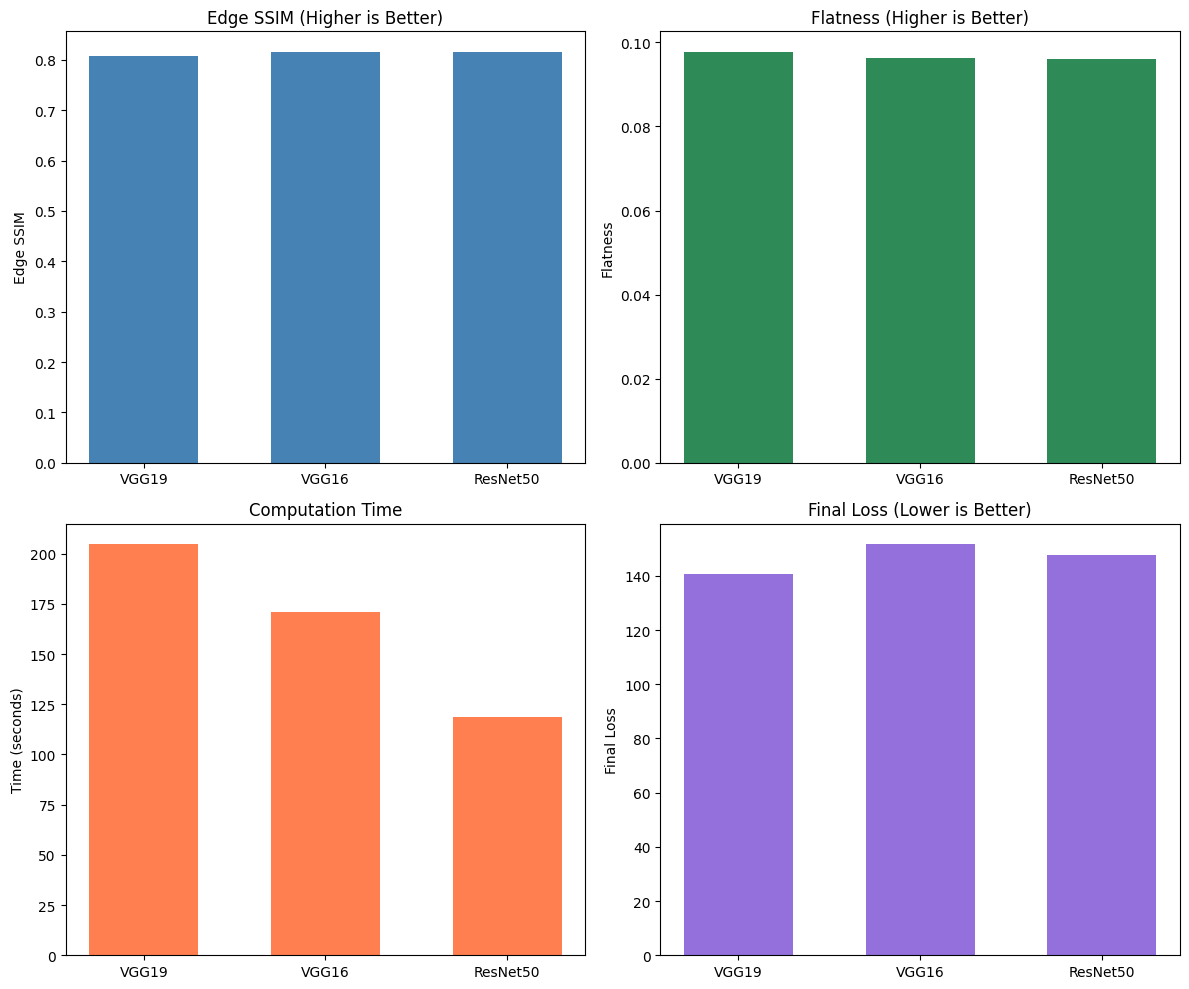

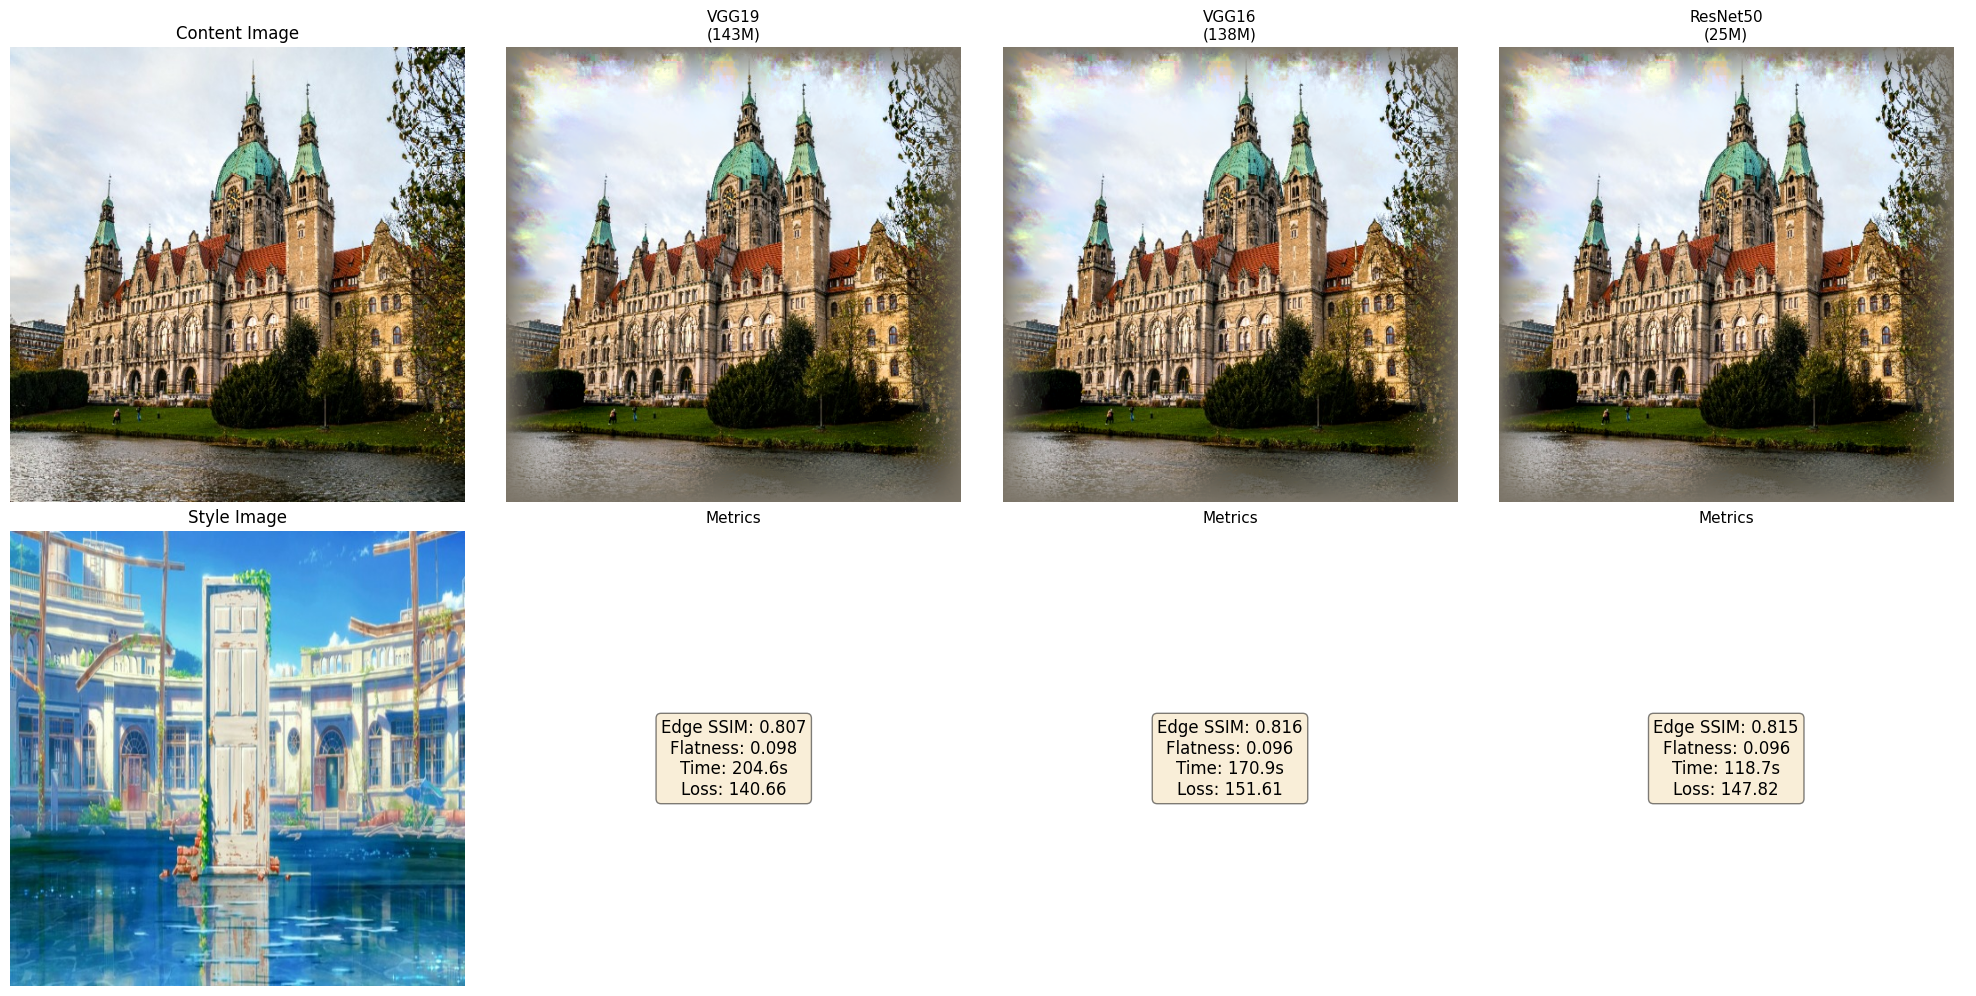

In [11]:
# 10. Results Analysis and Visualization

# Create results summary table
print("\n" + "="*80)
print("RESULTS SUMMARY TABLE")
print("="*80)

header = f"{'Extractor':<15} {'Params':<10} {'Time(s)':<10} {'Loss':<12} {'Edge SSIM':<12} {'Flatness':<10}"
print(header)
print("-" * 80)

for r in results:
    print(f"{r['name']:<15} {r['params']:<10} {r['time_seconds']:<10.2f} {r['final_loss']:<12.4f} {r['edge_ssim']:<12.4f} {r['flatness']:<10.4f}")


# Save results to CSV
csv_path = f"{RESULTS_DIR}/feature_extractor_comparison_results.csv"
with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Feature_Extractor', 'Parameters', 'Time_Seconds', 'Final_Loss', 
                     'Edge_SSIM', 'Flatness', 'Color_Variance', 'Gradient_Magnitude'])
    for r in results:
        writer.writerow([
            r['name'], r['params'], r['time_seconds'], r['final_loss'],
            r['edge_ssim'], r['flatness'], r['color_variance'], r['gradient_magnitude']
        ])
print(f"Results saved to {csv_path}")


# Plot loss curves comparison
plt.figure(figsize=(12, 6))

for r in results:
    plt.plot(r['loss_history'], label=f"{r['name']} ({r['params']})", linewidth=2)

plt.xlabel('L-BFGS Iterations', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Loss Convergence Comparison', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/loss_curves_comparison.png", dpi=150, bbox_inches='tight')
plt.show()


# Plot metrics comparison bar chart
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

names = [r['name'] for r in results]
x = np.arange(len(names))
bar_width = 0.6

# Edge SSIM
axes[0, 0].bar(x, [r['edge_ssim'] for r in results], bar_width, color='steelblue')
axes[0, 0].set_ylabel('Edge SSIM')
axes[0, 0].set_title('Edge SSIM (Higher is Better)')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(names)

# Flatness
axes[0, 1].bar(x, [r['flatness'] for r in results], bar_width, color='seagreen')
axes[0, 1].set_ylabel('Flatness')
axes[0, 1].set_title('Flatness (Higher is Better)')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(names)

# Time
axes[1, 0].bar(x, [r['time_seconds'] for r in results], bar_width, color='coral')
axes[1, 0].set_ylabel('Time (seconds)')
axes[1, 0].set_title('Computation Time')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(names)

# Final Loss
axes[1, 1].bar(x, [r['final_loss'] for r in results], bar_width, color='mediumpurple')
axes[1, 1].set_ylabel('Final Loss')
axes[1, 1].set_title('Final Loss (Lower is Better)')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(names)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/metrics_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# Visual comparison grid
n_results = len(results)

fig, axes = plt.subplots(2, n_results + 1, figsize=(5*(n_results+1), 10))

# Top row: Original images
axes[0, 0].imshow(original_image)
axes[0, 0].set_title('Content Image', fontsize=12)
axes[0, 0].axis('off')

for i, r in enumerate(results):
    axes[0, i+1].imshow(r['output_image'])
    axes[0, i+1].set_title(f"{r['name']}\n({r['params']})", fontsize=11)
    axes[0, i+1].axis('off')

# Bottom row: Style image and metrics
axes[1, 0].imshow(deprocess_image_vgg(style_image_vgg.numpy()))
axes[1, 0].set_title('Style Image', fontsize=12)
axes[1, 0].axis('off')

for i, r in enumerate(results):
    # Create text summary
    text = f"Edge SSIM: {r['edge_ssim']:.3f}\n"
    text += f"Flatness: {r['flatness']:.3f}\n"
    text += f"Time: {r['time_seconds']:.1f}s\n"
    text += f"Loss: {r['final_loss']:.2f}"
    
    axes[1, i+1].text(0.5, 0.5, text, ha='center', va='center', 
                       fontsize=12, transform=axes[1, i+1].transAxes,
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    axes[1, i+1].axis('off')
    axes[1, i+1].set_title('Metrics', fontsize=11)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/visual_comparison_grid.png", dpi=150, bbox_inches='tight')
plt.show()


In [13]:
# 11. Conclusions

# Find best results
if results:
    best_edge_ssim = max(results, key=lambda x: x['edge_ssim'])
    best_flatness = max(results, key=lambda x: x['flatness'])
    fastest = min(results, key=lambda x: x['time_seconds'])
    best_loss = min(results, key=lambda x: x['final_loss'])
    
    vgg19 = next((r for r in results if r['name'] == 'VGG19'), None)

print("\n" + "="*70)
print("EXPERIMENT C: FEATURE EXTRACTOR COMPARISON - CONCLUSIONS")
print("="*70)

if results:
    print(f"\nBest Edge SSIM: {best_edge_ssim['name']} ({best_edge_ssim['edge_ssim']:.4f})")
    print(f"Best Flatness: {best_flatness['name']} ({best_flatness['flatness']:.4f})")
    print(f"Fastest: {fastest['name']} ({fastest['time_seconds']:.2f}s)")
    print(f"Best Loss: {best_loss['name']} ({best_loss['final_loss']:.4f})")

print("\n" + "-"*70)
print("VGG19 Baseline Performance:")
if vgg19:
    print(f"  Edge SSIM: {vgg19['edge_ssim']:.4f}")
    print(f"  Flatness: {vgg19['flatness']:.4f}")
    print(f"  Time: {vgg19['time_seconds']:.2f}s")
    print(f"  Final Loss: {vgg19['final_loss']:.4f}")

print("\n" + "-"*70)
print("Feature Extractor Comparison:")
for r in results:
    if vgg19 and r['name'] != 'VGG19':
        edge_diff = ((r['edge_ssim'] - vgg19['edge_ssim']) / vgg19['edge_ssim']) * 100
        flat_diff = ((r['flatness'] - vgg19['flatness']) / vgg19['flatness']) * 100
        time_diff = ((r['time_seconds'] - vgg19['time_seconds']) / vgg19['time_seconds']) * 100
        print(f"  {r['name']} vs VGG19:")
        print(f"    Edge SSIM: {edge_diff:+.1f}%")
        print(f"    Flatness: {flat_diff:+.1f}%")
        print(f"    Time: {time_diff:+.1f}%")


print(f"\nResults saved to: {RESULTS_DIR}/")



EXPERIMENT C: FEATURE EXTRACTOR COMPARISON - CONCLUSIONS

Best Edge SSIM: VGG16 (0.8157)
Best Flatness: VGG19 (0.0977)
Fastest: ResNet50 (118.71s)
Best Loss: VGG19 (140.6573)

----------------------------------------------------------------------
VGG19 Baseline Performance:
  Edge SSIM: 0.8073
  Flatness: 0.0977
  Time: 204.60s
  Final Loss: 140.6573

----------------------------------------------------------------------
Feature Extractor Comparison:
  VGG16 vs VGG19:
    Edge SSIM: +1.0%
    Flatness: -1.4%
    Time: -16.5%
  ResNet50 vs VGG19:
    Edge SSIM: +1.0%
    Flatness: -1.8%
    Time: -42.0%

Results saved to: results_feature_extractor_comparison/
